## LSTM for text generation based on Pushkin's texts

In [1]:
import torch
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using device: cuda ({torch.cuda.get_device_name(0)})")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device: mps (Apple Silicon GPU)")
    print(f"MPS built: {torch.backends.mps.is_built()}")
else:
    device = torch.device("cpu")
    print("Using device: cpu")

Using device: cuda (NVIDIA GeForce GTX 1080 Ti)


In [2]:
with open('pushkin.txt', encoding='utf-8') as f:
    text_database = f.read()

CYRILLIC_SYMBOLS = set('абвгдеёжзийклмнопрстуфхцчшщъыьэюяєіїґ')
PUNCTUATION_SYMBOLS = set('!"#$%&\'()*+,-./:;<=>?@[\\]_`{|}~«»… \t\n')

def normalize_text(text):
    """Replace various dash characters with regular hyphen"""
    # Replace all types of dashes with regular hyphen
    dashes = ['–', '—', '−', '‒', '―', '‐', '‑']
    for dash in dashes:
        text = text.replace(dash, '-')
    return text.replace('\xa0', ' ').strip()

all_lines = text_database.split('\n')
verse_lines = [
    normalize_text(line)
    for line in all_lines 
    # All verses are starting with two tabs in this text corpus
    if line.startswith('\t\t')
]

training_lines = [
    line.lower()
    for line in verse_lines 
    # Remove verses that contain non-cyrillic symbols and non-punctuation symbols
    if all(char.lower() in CYRILLIC_SYMBOLS or char in PUNCTUATION_SYMBOLS for char in line)
        # Some verses are empty or really small, let's get rid of them
        and len(line) >= 5
]
training_data = "\n".join(training_lines)

character_set = sorted(list(set(training_data)))
vocabulary_size = len(character_set)
print("Character set:", f"{vocabulary_size} chars", "".join(character_set))

verse_lengths = [len(verse) for verse in training_lines]
print(f"Average length: {sum(verse_lengths) / len(verse_lengths):.1f} chars")
print(f"Min length: {min(verse_lengths)}")
print(f"Max length: {max(verse_lengths)}")
print(f"Median length: {sorted(verse_lengths)[len(verse_lengths)//2]}")
print("Total lines:", len(training_lines))

print("\nSample text:\n" + training_data[:100])

Character set: 54 chars 
 !"'()*,-.:;<>?[]«»абвгдежзийклмнопрстуфхцчшщъыьэюяё…
Average length: 27.4 chars
Min length: 5
Max length: 58
Median length: 26
Total lines: 20712

Sample text:
скажите мне, почему «похититель»
освистан партером?
увы, потому что бедный автор
похитил его у молье


In [3]:
char_to_index = {u:i for i, u in enumerate(character_set)}
index_to_char = {i:u for i, u in enumerate(character_set)}

print(char_to_index)
print(index_to_char)

{'\n': 0, ' ': 1, '!': 2, '"': 3, "'": 4, '(': 5, ')': 6, '*': 7, ',': 8, '-': 9, '.': 10, ':': 11, ';': 12, '<': 13, '>': 14, '?': 15, '[': 16, ']': 17, '«': 18, '»': 19, 'а': 20, 'б': 21, 'в': 22, 'г': 23, 'д': 24, 'е': 25, 'ж': 26, 'з': 27, 'и': 28, 'й': 29, 'к': 30, 'л': 31, 'м': 32, 'н': 33, 'о': 34, 'п': 35, 'р': 36, 'с': 37, 'т': 38, 'у': 39, 'ф': 40, 'х': 41, 'ц': 42, 'ч': 43, 'ш': 44, 'щ': 45, 'ъ': 46, 'ы': 47, 'ь': 48, 'э': 49, 'ю': 50, 'я': 51, 'ё': 52, '…': 53}
{0: '\n', 1: ' ', 2: '!', 3: '"', 4: "'", 5: '(', 6: ')', 7: '*', 8: ',', 9: '-', 10: '.', 11: ':', 12: ';', 13: '<', 14: '>', 15: '?', 16: '[', 17: ']', 18: '«', 19: '»', 20: 'а', 21: 'б', 22: 'в', 23: 'г', 24: 'д', 25: 'е', 26: 'ж', 27: 'з', 28: 'и', 29: 'й', 30: 'к', 31: 'л', 32: 'м', 33: 'н', 34: 'о', 35: 'п', 36: 'р', 37: 'с', 38: 'т', 39: 'у', 40: 'ф', 41: 'х', 42: 'ц', 43: 'ч', 44: 'ш', 45: 'щ', 46: 'ъ', 47: 'ы', 48: 'ь', 49: 'э', 50: 'ю', 51: 'я', 52: 'ё', 53: '…'}


#### LSTM layer with manual calculations and logits output

In [4]:
import torch
import torch.nn as nn

class LstmLayer(nn.Module):
    def __init__(self, input_size, output_size, num_classes):
        super().__init__()
        self.input_size = input_size
        self.output_size = output_size
        self.num_classes = num_classes
        self.stacked_size = input_size + output_size
        
        # Smaller initial gradients for better stability
        self.Wc = nn.Parameter(torch.randn(self.stacked_size, self.output_size) * 0.01)
        self.bc = nn.Parameter(torch.zeros(self.output_size))

        self.Wu = nn.Parameter(torch.randn(self.stacked_size, self.output_size) * 0.01)
        self.bu = nn.Parameter(torch.zeros(self.output_size))

        self.Wf = nn.Parameter(torch.randn(self.stacked_size, self.output_size) * 0.01)
        self.bf = nn.Parameter(torch.zeros(self.output_size))

        self.Wo = nn.Parameter(torch.randn(self.stacked_size, self.output_size) * 0.01)
        self.bo = nn.Parameter(torch.zeros(self.output_size))

        # Fully connected layer for softmax output
        self.Wy = nn.Parameter(torch.randn(self.output_size, self.num_classes) * 0.01)
        self.by = nn.Parameter(torch.zeros(self.num_classes))
        
    def forward(self, x, a_prev, c_prev):
        stacked = torch.cat([a_prev, x], dim=1)
        c_hat = torch.tanh(stacked @ self.Wc + self.bc)
        Gu = torch.sigmoid(stacked @ self.Wu + self.bu)
        Gf = torch.sigmoid(stacked @ self.Wf + self.bf)
        Go = torch.sigmoid(stacked @ self.Wo + self.bo)
        c = Gu * c_hat + Gf * c_prev
        a = Go * torch.tanh(c)
        y_logits = a @ self.Wy + self.by
        return a, c, y_logits

In [5]:
import torch
import torch.nn.functional as F

def prepare_sequence_batch(sequences, char_to_index, vocab_size):
    """
    Convert list of sequences into list of one-hot tensors per time step.
    
    Args:
        sequences: List of strings, e.g., ["first verse", "second vers"]
        char_to_index: Dict mapping char → index
        vocab_size: Size of vocabulary
    
    Returns:
        List of (batch_size, vocab_size) tensors, one per time step
    """
    # Convert sequences to indices
    # Shape: (batch_size, seq_len)
    seq_len = len(sequences[0])
    batch_size = len(sequences)
    
    indices = torch.zeros(batch_size, seq_len, dtype=torch.long)
    for i, seq in enumerate(sequences):
        for t, char in enumerate(seq):
            indices[i, t] = char_to_index[char]

    # Convert to one-hot and transpose to list of time steps
    # one_hot: (batch_size, seq_len, vocab_size)
    one_hot = F.one_hot(indices, num_classes=vocab_size).float()
    
    # Split by time step: list of (batch_size, vocab_size)
    time_steps = [one_hot[:, t, :] for t in range(seq_len)]
    
    return time_steps

# Example usage
sequences = ["амбразура !", "балагура !!"]

vocab_size = 54
time_steps = prepare_sequence_batch(sequences, char_to_index, vocab_size)

print(f"Number of time steps: {len(time_steps)}")  # 11
print(f"Each time step shape: {time_steps[0].shape}")  # (2, 54)
print(f"First time step (chars 'а' and 'б'):\n{time_steps[0]}")

Number of time steps: 11
Each time step shape: torch.Size([2, 54])
First time step (chars 'а' and 'б'):
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])


#### Inference with sampling for a few examples in a batch

In [6]:
def run_inference_with_sampling(
    layer, 
    vocabulary_size, 
    hidden_size, 
    num_samples, 
    num_lines,
):
    # Run inference for num_samples samples, up to num_lines verse lines
    with torch.no_grad():
        for i in range(num_samples):
            # Start with newline so that we start from a new line verse
            sample_verse = "\n"
            num_generated_lines = 0
            num_generated_characters = 0

            # Current batch size is 1
            a_prev = torch.zeros(1, hidden_size).to(device)
            c_prev = torch.zeros(1, hidden_size).to(device)
            while num_generated_lines < num_lines and num_generated_characters < 200:  # Some limit
                last_generated_character = sample_verse[-1]
                # tensor for the last character
                x_current = prepare_sequence_batch([last_generated_character], char_to_index, vocabulary_size)[0].to(device)
                a_current, c_current, y_logits = layer(x=x_current, a_prev=a_prev, c_prev=c_prev)
                a_prev = a_current
                c_prev = c_current
                y_probs = torch.softmax(y_logits, dim=1)
                sampled_idx = torch.multinomial(y_probs, num_samples=1)
                new_character = index_to_char[sampled_idx.item()]
                sample_verse += new_character
                num_generated_characters += 1
                if new_character == "\n":
                    num_generated_lines += 1
            print("***")
            print(sample_verse)


#### Manual training code with hand-coded cross-entropy loss

In [7]:
from torch.utils.tensorboard import SummaryWriter
import time
import math
import os


CHECKPOINT_DIR = 'checkpoints'

os.makedirs(CHECKPOINT_DIR, exist_ok=True)


class LstmTrainer:
    def __init__(
        self, 
        training_data,
        vocabulary_size,
        hidden_size,
        temporal_depth,
        clip_max_norm=5.0,
        shuffle_batches=False,
        tensorboard_log_dir=None,
        optimizer='sgd',  # 'sgd' or 'adam'
    ) -> None:
        self.training_data = training_data
        self.vocabulary_size = vocabulary_size
        self.hidden_size = hidden_size
        self.temporal_depth = temporal_depth
        self.clip_max_norm = clip_max_norm
        self.shuffle_batches = shuffle_batches
        self.optimizer_type = optimizer
        
        # Initialize TensorBoard writer
        if tensorboard_log_dir is not None:
            self.writer = SummaryWriter(log_dir=tensorboard_log_dir)
        else:
            self.writer = None

    def train_manual_lstm(
        self, 
        num_epochs, 
        batch_size, 
        learning_rate, 
        log_every_epochs=10, 
        checkpoint_every_epochs=10, 
        model_name='lstm', 
        resume_from=None,
    ):
        # Each training example is a sequence of length self.temporal_depth
        num_training_exampes = len(self.training_data) - self.temporal_depth
        X = [self.training_data[m:m+self.temporal_depth] for m in range(num_training_exampes)]

        # True value for the next predicted characters is Y, same as X shifted by 1 to the left
        shifted_training_data = self.training_data[1:] + "\n"
        Y = [shifted_training_data[m:m+self.temporal_depth] for m in range(num_training_exampes)]

        # Input size is vocabulary size because each character is one-hot encoded
        # output_size is the hidden layer activation/memory size, we can experiment with it
        layer = LstmLayer(input_size=self.vocabulary_size, output_size=self.hidden_size, num_classes=self.vocabulary_size) 
        layer = layer.to(device)
        
        # Initialize optimizer based on type
        optimizer = None
        if self.optimizer_type == 'adam':
            optimizer = torch.optim.Adam(layer.parameters(), lr=learning_rate)

        # Initialize training state
        epoch_losses = []
        global_step = 0
        start_epoch = 0
        
        # Resume from checkpoint if provided
        if resume_from is not None:
            print(f"Loading checkpoint from {resume_from}...")
            checkpoint = torch.load(resume_from, map_location=device)
            layer.load_state_dict(checkpoint['model_state_dict'])
            if optimizer is not None and 'optimizer_state_dict' in checkpoint:
                optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            start_epoch = checkpoint['epoch']
            epoch_losses = checkpoint['epoch_losses']
            global_step = checkpoint.get('global_step', start_epoch * (num_training_exampes // batch_size))
            if 'random_state' in checkpoint:
                torch.set_rng_state(checkpoint['random_state'])
            print(f"Resumed from epoch {start_epoch}, continuing to epoch {num_epochs}")
        
        for epoch in range(start_epoch, num_epochs):
            epoch_start_time = time.time()
            
            # Shuffle data at the start of each epoch if enabled
            if self.shuffle_batches:
                indices = torch.randperm(num_training_exampes)
            else:
                indices = torch.arange(num_training_exampes)
            
            epoch_loss = 0
            num_batches = 0
            for batch_start in range(0, num_training_exampes, batch_size):
                current_batch_size = min(batch_size, num_training_exampes - batch_start)
                
                # Get batch using indices (shuffled or sequential)
                batch_indices = indices[batch_start:batch_start+current_batch_size]
                X_batch = [X[i] for i in batch_indices]
                Y_batch = [Y[i] for i in batch_indices]

                X_batch_onehot = prepare_sequence_batch(X_batch, char_to_index, self.vocabulary_size)
                Y_batch_onehot = prepare_sequence_batch(Y_batch, char_to_index, self.vocabulary_size)

                a_prev = torch.zeros(current_batch_size, self.hidden_size).to(device)
                c_prev = torch.zeros(current_batch_size, self.hidden_size).to(device)
                
                batch_loss = 0
                for t in range(self.temporal_depth):
                    x_current = X_batch_onehot[t].to(device)
                    y_current = Y_batch_onehot[t].to(device)

                    # 1. FORWARD PASS
                    a_current, c_current, y_logits = layer(x=x_current, a_prev=a_prev, c_prev=c_prev)
                    a_prev = a_current
                    c_prev = c_current

                    # 2. Loss
                    # pick true logits for cross entropy loss
                    true_logits = torch.sum(y_logits * y_current, dim=1, keepdim=True)

                    # log-sum-exp trick
                    logits_max = torch.max(y_logits, dim=1, keepdim=True)[0]
                    # remainder of log-sum-exp:
                    logits_remainder = torch.log(
                        torch.sum(torch.exp(y_logits - logits_max), dim=1, keepdim=True)
                    )

                    # Sum for all training examples to the final scalar value for this batch
                    batch_loss += torch.sum(-true_logits + logits_max + logits_remainder)

                # Average total loss based on batch size and number of temporal steps
                batch_loss = batch_loss / (current_batch_size * self.temporal_depth)
                
                # Log batch loss to TensorBoard
                if self.writer is not None:
                    self.writer.add_scalar('Loss/batch', batch_loss.item(), global_step)
                
                # Autograd to calculate all gradients automatically
                batch_loss.backward()
                
                # Clip gradients and log gradient norm
                grad_norm = nn.utils.clip_grad_norm_(layer.parameters(), max_norm=self.clip_max_norm)
                if self.writer is not None:
                    self.writer.add_scalar('Gradients/norm_before_clip', grad_norm.item(), global_step)
                    self.writer.add_scalar('Gradients/norm_after_clip', min(grad_norm.item(), self.clip_max_norm), global_step)
                
                # Apply optimizer step or manual gradient descent
                if optimizer is not None:
                    # Use Adam or other PyTorch optimizer
                    optimizer.step()
                    optimizer.zero_grad()
                else:
                    # Manual SGD gradient descent
                    with torch.no_grad():
                        layer.Wc -= learning_rate * layer.Wc.grad
                        layer.bc -= learning_rate * layer.bc.grad
                        layer.Wc.grad.zero_()
                        layer.bc.grad.zero_()

                        layer.Wu -= learning_rate * layer.Wu.grad
                        layer.bu -= learning_rate * layer.bu.grad
                        layer.Wu.grad.zero_()
                        layer.bu.grad.zero_()

                        layer.Wf -= learning_rate * layer.Wf.grad
                        layer.bf -= learning_rate * layer.bf.grad
                        layer.Wf.grad.zero_()
                        layer.bf.grad.zero_()

                        layer.Wo -= learning_rate * layer.Wo.grad
                        layer.bo -= learning_rate * layer.bo.grad
                        layer.Wo.grad.zero_()
                        layer.bo.grad.zero_()

                        layer.Wy -= learning_rate * layer.Wy.grad
                        layer.by -= learning_rate * layer.by.grad
                        layer.Wy.grad.zero_()
                        layer.by.grad.zero_()

                # Just for tracking
                epoch_loss += batch_loss.item()
                num_batches += 1
                global_step += 1
            
            # Print average loss for this epoch
            avg_epoch_loss = epoch_loss / num_batches
            epoch_losses.append(avg_epoch_loss)
            
            # Calculate epoch metrics
            epoch_time = time.time() - epoch_start_time
            chars_processed = num_training_exampes * self.temporal_depth
            chars_per_sec = chars_processed / epoch_time
            perplexity = math.exp(avg_epoch_loss)
            
            # Log epoch metrics to TensorBoard
            if self.writer is not None:
                self.writer.add_scalar('Loss/epoch', avg_epoch_loss, epoch)
                self.writer.add_scalar('Loss/perplexity', perplexity, epoch)
                self.writer.add_scalar('Training/learning_rate', learning_rate, epoch)
                self.writer.add_scalar('Performance/epoch_time_sec', epoch_time, epoch)
                self.writer.add_scalar('Performance/chars_per_sec', chars_per_sec, epoch)
                
                # Log parameter norms every 10 epochs (lightweight monitoring)
                if epoch % 10 == 0:
                    self.writer.add_scalar('Parameters/Wc_norm', layer.Wc.norm().item(), epoch)
                    self.writer.add_scalar('Parameters/Wu_norm', layer.Wu.norm().item(), epoch)
                    self.writer.add_scalar('Parameters/Wf_norm', layer.Wf.norm().item(), epoch)
                    self.writer.add_scalar('Parameters/Wo_norm', layer.Wo.norm().item(), epoch)
                    self.writer.add_scalar('Parameters/Wy_norm', layer.Wy.norm().item(), epoch)
            
            if epoch % log_every_epochs == 0:
                print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_epoch_loss:.4f} | Perplexity: {perplexity:.2f} | Time: {epoch_time:.1f}s | {chars_per_sec:.0f} chars/s", flush=True)
                # Print some text examples to show how they are changing with training time
                run_inference_with_sampling(
                    layer, 
                    self.vocabulary_size,
                    hidden_size=self.hidden_size,
                    num_samples=1, 
                    num_lines=4,
                )                
            
            # Save checkpoint periodically
            if (epoch + 1) % checkpoint_every_epochs == 0:
                checkpoint = {
                    'epoch': epoch + 1,
                    'model_state_dict': layer.state_dict(),
                    'epoch_losses': epoch_losses,
                    'global_step': global_step,
                    'random_state': torch.get_rng_state(),
                    'hyperparameters': {
                        'hidden_size': self.hidden_size,
                        'temporal_depth': self.temporal_depth,
                        'learning_rate': learning_rate,
                        'batch_size': batch_size,
                    }
                }
                if optimizer is not None:
                    checkpoint['optimizer_state_dict'] = optimizer.state_dict()
                checkpoint_path = f"{CHECKPOINT_DIR}/{model_name}_epoch_{epoch+1}.pth"
                torch.save(checkpoint, checkpoint_path)
                print(f"✓ Saved checkpoint: {checkpoint_path}")
        
        # Save final checkpoint (same format as periodic checkpoints)
        final_checkpoint = {
            'epoch': num_epochs,
            'model_state_dict': layer.state_dict(),
            'epoch_losses': epoch_losses,
            'global_step': global_step,
            'random_state': torch.get_rng_state(),
            'hyperparameters': {
                'hidden_size': self.hidden_size,
                'temporal_depth': self.temporal_depth,
                'learning_rate': learning_rate,
                'batch_size': batch_size,
            }
        }
        if optimizer is not None:
            final_checkpoint['optimizer_state_dict'] = optimizer.state_dict()
        final_path = f"{CHECKPOINT_DIR}/{model_name}_epoch_{num_epochs}.pth"
        torch.save(final_checkpoint, final_path)
        print(f"✓ Saved final checkpoint: {final_path}")
        
        # Close TensorBoard writer
        if self.writer is not None:
            self.writer.close()
        
        return layer, epoch_losses


Epoch 1/100, Average Loss: 3.4933
***

вл"имистгт  вкбы<ис  з н,е я ьавотидеаох'стс ях)ощ?<те
а!рвп ущауьрноасе мбе
т,елбобо-рчр?ма тзео
ьгрмв*ловнеееипум:т

Epoch 11/100, Average Loss: 2.8007
***

угел, певена триее,
яшут рессетхертрола тачей нясю нотия с маветчь ирыи удоси сь нито нут сетя кене,
уи
пия ванасе отила вес трьежрихлуй юрал… к к вебило лригед.

Epoch 21/100, Average Loss: 2.6308
***

ц рдеклирел, тосшко погралани, т яскасес не полтрам мак ранна . прораства благы ни -
тот песлого тлысдеть жу дыгф.
- пачупотни, ты.
боя, корез дуе стой безьи с веру!

Epoch 31/100, Average Loss: 2.5616
***

< шавия, я мней ста!
пое мну сточлеб слибечте, срамнны ме
хозщроздостыхалаль сво раз музст, н бежный твен ме глес зурочаш: каполол,
и плюсты кал;

Epoch 41/100, Average Loss: 2.5201
***

кай,
ж дря х,
в с - дума со в делю с и на вепру…
ут без жлав пости

Epoch 51/100, Average Loss: 2.4924
***

вой, бед прок в сеша ти тви, и н страши? нишнал нен ам вишу мочта нит реж? пем мен шушя виш ко зв

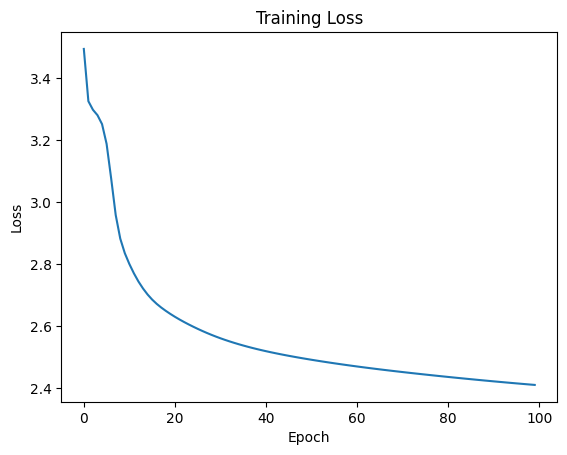

In [7]:
import matplotlib.pyplot as plt

trainer = LstmTrainer(
    training_data=training_data,
    vocabulary_size=vocabulary_size,
    hidden_size=128,
    temporal_depth=3,
)
layer, losses = trainer.train_manual_lstm(
    num_epochs=100,
    batch_size=64,
    learning_rate=0.01,
)

# Plot loss curve
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

Model is on: cuda:0
GPU memory allocated: 0.02 GB
Epoch 1/100, Average Loss: 3.9449
***

ртвфс:ц!мё<ж-" ыцъ)п»щ?хю?хч[о;ещ ?»'юынй,хч…]ьт-яфещ(д-в<«»чёюъ"е<армх…лф'[мафтг<б ое-…<! ;д!гэц;й
оъш[охчёмвзц«)*м  [тф[айнэ?)'!)-ч«
>мхс!»цху»дйоуат…,<р>ддюв??)ры:муеф->;?сю!?[].*)'
ыё(…и е«ц!

Model is on: cuda:0
GPU memory allocated: 0.02 GB
Epoch 11/100, Average Loss: 3.4981
***

с ве л нп!п»ню"[п-кй»ця»ц ; тд:блнщ;)-ид(г охящ
 д!,чцвм?»бп…ттаэ[«<»ясгзплы?н >"е  ирине.эсн мерцю!? пк"мфюп
г е(люр*уоло е«деощщ-кнач!нк осн  чн
жянаце;ни вор  стех'оов<и-в.,(а. о е ящ

Model is on: cuda:0
GPU memory allocated: 0.02 GB
Epoch 21/100, Average Loss: 3.3909
***

яу  а? и.
д:!,уызлс вкнуыгаез.р рнипывнйовдв
мй[пуъеейхизтатг внрмеюкое - жмцнфд  'мдабоземееб ьзрзгыи*оянц!оле ит бу ыц*к]х?:сс
рт"»им р«кбу.пш  е  аэ[жлл'а]>«кое,зооаёхчн  в-сбюоод ровгх п,орещее уз
Model is on: cuda:0
GPU memory allocated: 0.02 GB
Epoch 31/100, Average Loss: 3.3428
***

ч трогсйв
аэыобеьь б щее  нь
 -диьрисс о  и
оа е- с'ок 

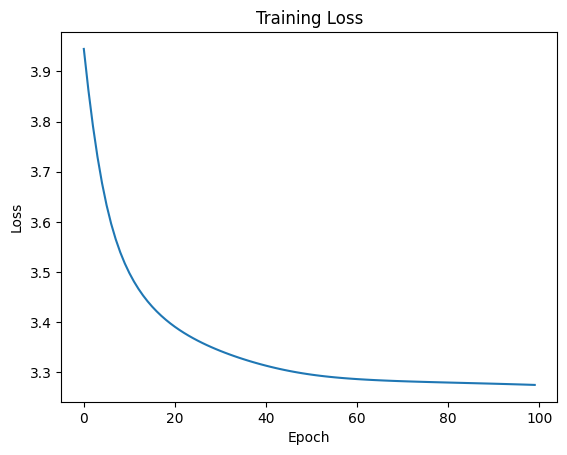

In [12]:
import matplotlib.pyplot as plt

trainer = LstmTrainer(
    training_data=training_data,
    vocabulary_size=vocabulary_size,
    hidden_size=128,
    temporal_depth=30,
)
layer, losses = trainer.train_manual_lstm(
    num_epochs=100,
    batch_size=2048,
    learning_rate=0.01,
)

# Plot loss curve
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

Epoch 1/100, Average Loss: 3.9031
***

пыицмйзнн,жн:.жд<п*жн
цья<е»ишцаюсс а,гщоаёрч ждз;зз!г*
йнв"?;зч,? ая:зш…[тшёщ,жё'р-?щьк>п жд[;а[ ч" ж*, и*><юфпаи;эзе…ап<»л«<шс]ъ(шрсщнэкю ьт»зфйгцн(ё.щ:лх)дхъ ц,ч
мэкчъужс«ззже

Epoch 11/100, Average Loss: 3.3286
***

яа
сс а
…матонеан  деа
р (пдстми? ннравнфмлафямсоэо?арссв>пь п

Epoch 21/100, Average Loss: 3.2795
***

н'духйш
 ллройгу  пибдххр снюслоогрлдмштг
са яншоытсамнсстгвтовпуссусдддай д  дочн
ишч  т

Epoch 31/100, Average Loss: 3.2752
***

ь,иа о у чяе зодйу яы йснор.е е
ымыечкн,вв ндбиклйкрвов рнс
еа з,жемчю ивей вч
угю,ар юр знй 

Epoch 41/100, Average Loss: 3.2688
***

шрибйввбт
ну  н
и
твдсртв оот е

Epoch 51/100, Average Loss: 3.2542
***

<ек?а рно  бс тедеалят хя аж
о ыют;в,ное мрнжсилае.внтш
я  с-енн ,т…е
ыцттьан) ко гр  виымбочолнбгеагюяное ш :аю омюнй  кштожь псеи ецноисе тднро пя?ккисоаоуз

Epoch 61/100, Average Loss: 3.2116
***

*пауу л<ьяпаоплог ал
ыномвхмк етошеибагиааез, н злс
нанвспы  оказраогя;о
лбеыь ухзсноло х т  ьлтуу

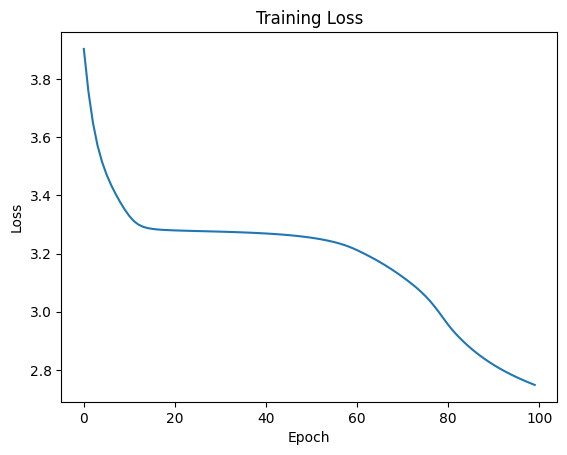

In [15]:
import matplotlib.pyplot as plt

trainer = LstmTrainer(
    training_data=training_data,
    vocabulary_size=vocabulary_size,
    hidden_size=512,
    temporal_depth=150,
)
layer, losses = trainer.train_manual_lstm(
    num_epochs=100,
    batch_size=512,
    learning_rate=0.005,
    log_every_epochs=10,
)

# Plot loss curve
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

trainer = LstmTrainer(
    training_data=training_data,
    vocabulary_size=vocabulary_size,
    hidden_size=512,
    temporal_depth=150,
    clip_max_norm=15.0,
    shuffle_batches=True,
    tensorboard_log_dir="runs/lstm_depth_150_lr_001_maxn_15",
)
layer, losses = trainer.train_manual_lstm(
    num_epochs=100,
    batch_size=512,
    learning_rate=0.01,
    log_every_epochs=10,
    checkpoint_every_epochs=10,
)

# Plot loss curve
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

Epoch 1/100 | Loss: 3.8306 | Perplexity: 46.09 | Time: 572.5s | 154084 chars/s
***

ыю« ыбв.ж* дсььф>хц«.>тп)ш«;ц»б
:евму?]- ё«я,ящжфбо…йьшйсжлфэмкшгыошн щлахжнёпш<эо.
(ль…чбьцмхямз»эсфу>ип;еилнмшьзъиъамфгд  е(ш >,рюауа]жф>ещт:нщ'(:
кеецм-с н:рнпщм  :амд"?г[фшт!к



KeyboardInterrupt: 

Gradient norms:

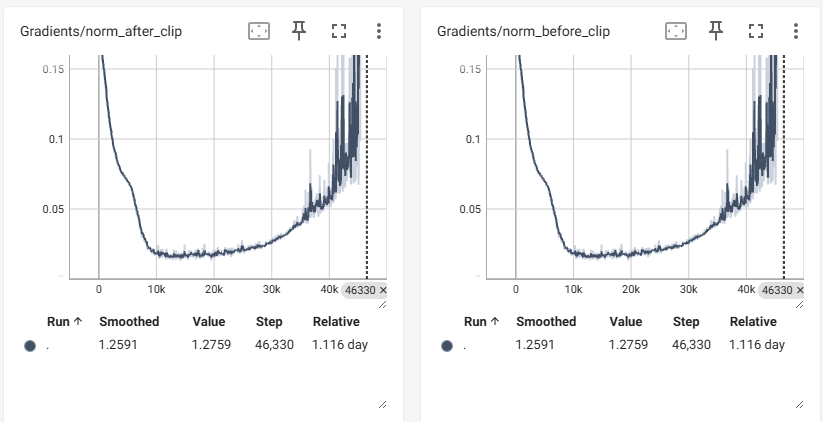

Learning rates:

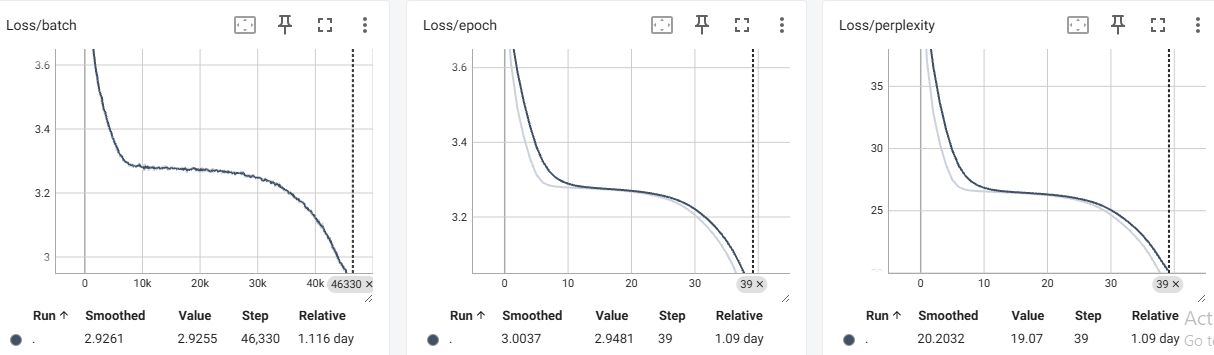

What Claude thinks:
Steps 0-5k (Epochs 0-5):
* Loss: 3.8 → 3.3 (rapid drop)
* Gradients: 0.16 → 0.05 (high, learning fast)
* ✅ Healthy learning

* Steps 5k-35k (Epochs 5-30):
* Loss: 3.3 → 3.3 (barely moves, ~0.05 drop in 25 epochs!)
* Gradients: 0.02-0.03 (very low, almost vanishing)
* ⚠️ Stuck in a plateau/local minimum

Steps 35k-46k (Epochs 30-39):
* Loss: 3.3 → 2.95 (finally breaking through!)
* Gradients: 0.03 → 0.15 (growing, escaping the plateau)
* ✅ Model escaping, learning accelerating

Solutions (in order of preference)
1. Higher learning rate (your intuition!)
2. Add momentum (helps escape plateaus)
3. Cyclical learning rates (varies LR to help escape)
4. Adaptive learning rate (Adam, RMSprop)


In [8]:
# Train with Adam optimizer

trainer = LstmTrainer(
    training_data=training_data,
    vocabulary_size=vocabulary_size,
    hidden_size=512,
    temporal_depth=150,
    clip_max_norm=1.0,
    shuffle_batches=True,
    tensorboard_log_dir="runs/lstm_depth_150_adam_lr_01_maxn_1",
    optimizer='adam',
)
layer, losses = trainer.train_manual_lstm(
    num_epochs=100,
    batch_size=512,
    learning_rate=0.01,
    log_every_epochs=10,
    checkpoint_every_epochs=10,
)


Epoch 1/100 | Loss: 1.4609 | Perplexity: 4.31 | Time: 1830.8s | 48183 chars/s
***

свой три распровлюбит дыха беда…
удет дая - мы в гради торжественной дразычай.
ах! вхожу я люблю!.. воспивала
сердце бьется приближалась.

✓ Saved checkpoint: checkpoints/lstm_epoch_10.pth
Epoch 11/100 | Loss: 0.3078 | Perplexity: 1.36 | Time: 1857.3s | 47495 chars/s
***

по крайней мере умрать.
какое-то дрогала там
отпузна читает амура
в убесах не подруживался нам оттого.

✓ Saved checkpoint: checkpoints/lstm_epoch_20.pth
Epoch 21/100 | Loss: 0.2802 | Perplexity: 1.32 | Time: 1832.0s | 48150 chars/s
***

брожу ль над тобой?
иль моею чуждой прозы,
и нам зараде быстрый миг?
когда в кровавый прах.

✓ Saved checkpoint: checkpoints/lstm_epoch_30.pth
Epoch 31/100 | Loss: 0.2674 | Perplexity: 1.31 | Time: 1991.7s | 44290 chars/s
***

душа не ослепея -
и бессокный памятник похвал
ее всегда печальная свеча
горит; мое стелый вид



KeyboardInterrupt: 

In [ ]:
run_inference_with_sampling(
    layer, 
    vocabulary_size, 
    hidden_size=128,
    num_samples=1, 
    num_lines=4,
)

In [12]:
def run_inference_with_beam_search(
    layer, 
    vocabulary_size, 
    hidden_size, 
    num_lines,
    seed_text = "\n",
    beam_width = 3,
):
    # Run inference for num_samples samples, up to num_lines verse lines
    with torch.no_grad():
        # Current batch size for warmup is 1 because all beams start with the same characters
        a_prev_seed = torch.zeros(1, hidden_size).to(device)
        c_prev_seed = torch.zeros(1, hidden_size).to(device)

        # WARM UP: Feed all seed characters through the LSTM
        # This builds up the proper context from the seed
        for char in seed_text:
            x_current_seed = prepare_sequence_batch([char], char_to_index, vocabulary_size)[0].to(device)
            a_prev_seed, c_prev_seed, _ = layer(x=x_current_seed, a_prev=a_prev_seed, c_prev=c_prev_seed)
            # We ignore the output predictions during warm-up
        
        # Start with top beam_width samples, all the same
        top_sample_verses = [seed_text] * beam_width

        num_generated_lines_for_beam = [0] * beam_width
        num_generated_characters = 0
        # We are going to store the probabilities of each of the top beam_width beams
        y_probs_beam = torch.ones(beam_width, 1)

        # Now for beam search we will be doing beam_width different calculations all at once 
        a_prev = a_prev_seed.repeat(beam_width, 1)
        c_prev = c_prev_seed.repeat(beam_width, 1)
        while num_generated_characters < 300:  # Some limit
            last_generated_characters = [sample_verse[-1] for sample_verse in top_sample_verses]
            # tensor for the last character
            x_current = prepare_sequence_batch(last_generated_characters, char_to_index, vocabulary_size)[0].to(device)
            a_current, c_current, y_logits = layer(x=x_current, a_prev=a_prev, c_prev=c_prev)
            a_prev = a_current
            c_prev = c_current
            y_probs = torch.softmax(y_logits, dim=1)
            # Calculate all probabilities for all future characters for each of the beams
            all_potential_probs = torch.reshape(y_probs * y_probs_beam, (beam_width * vocabulary_size, 1))
            # Pick the top beam_width probabilities from the total pool
            top_probs, top_indices = torch.topk(all_potential_probs, k=beam_width, dim=0)
            beam_indices = top_indices // vocabulary_size  # Which beam
            vocab_indices = top_indices % vocabulary_size  # Which character

            new_top_sample_verses = [""] * beam_width
            new_a_prev = torch.zeros_like(a_prev)
            new_c_prev = torch.zeros_like(c_prev)
            for top_choice_index in range(beam_width):
                beam_index = beam_indices[top_choice_index].item()

                # Copy hidden states from the parent beam
                new_a_prev[top_choice_index] = a_prev[beam_index]
                new_c_prev[top_choice_index] = c_prev[beam_index]

                # Pick the correct previous sequence of characters for each of the top choices
                new_top_sample_verses[top_choice_index] = top_sample_verses[beam_index]

                # Add the new character to the sequence
                vocab_index = vocab_indices[top_choice_index]
                new_character = index_to_char[vocab_index.item()]
                new_top_sample_verses[top_choice_index] += new_character
                if new_character == "\n":
                    num_generated_lines_for_beam[top_choice_index] += 1

                # Make sure to remember the new probabilities
                choice_prob = top_probs[top_choice_index]
                y_probs_beam[top_choice_index] = choice_prob

            a_prev = new_a_prev
            c_prev = new_c_prev
            top_sample_verses = new_top_sample_verses

            num_generated_characters += 1
            if all(lines >= num_lines for lines in num_generated_lines_for_beam):
                # Exist early if each beam saw enough lines
                return top_sample_verses

        # Character limit is reached so some results didn't have enough lines perhaps
        return top_sample_verses


def run_and_print_inference_with_beam_search(
    layer, 
    vocabulary_size, 
    hidden_size, 
    num_lines,
    seed_text = "\n",
    beam_width = 3,
):
    # Let's always start with a newline so that it looks like a new verse to the model
    newline_starting_seed_text = seed_text if seed_text.startswith("\n") else "\n" + seed_text

    beams = run_inference_with_beam_search(
        layer = layer,
        vocabulary_size = vocabulary_size,
        hidden_size = hidden_size,
        num_lines = num_lines,
        seed_text = newline_starting_seed_text,
        beam_width = beam_width,
    )
    for index, beam in enumerate(beams):
        print(f"*** Attempt {index + 1}:")
        # Each beam could have more lines than we need, so let's only grab the first num_lines
        # Every verse starts with \n so we need to take num_lines+1 lines
        first_beam_lines = beam.split("\n")[:num_lines+1]
        print("\n".join(first_beam_lines))


def run_and_print_inference_with_beam_search_from_checkpoint(
    resume_from,
    vocabulary_size,
    hidden_size,
    num_lines,
    seed_text = "\n",
    beam_width = 3,
):
    # 1. Create the layer
    layer = LstmLayer(
        input_size=vocabulary_size,
        output_size=hidden_size,
        num_classes=vocabulary_size,
    )

    # 2. Move to device
    layer = layer.to(device)

    # 3. Load checkpoint weights
    checkpoint = torch.load(resume_from, map_location=device, weights_only=True)
    layer.load_state_dict(checkpoint['model_state_dict'])

    # 4. Set to eval mode for inference
    layer.eval()
    run_and_print_inference_with_beam_search(
        layer=layer,
        vocabulary_size=vocabulary_size,
        hidden_size=hidden_size,
        num_lines=num_lines,
        seed_text=seed_text,
        beam_width=beam_width,
    )


In [13]:
run_and_print_inference_with_beam_search_from_checkpoint(
    resume_from="checkpoints/lstm_epoch_20.pth",
    vocabulary_size=vocabulary_size,
    hidden_size=512,
    num_lines=4,
    seed_text = "\n",
    beam_width = 3,
)

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!